#ACTIVIDAD DIDÁCTICA 2 — MODELO OCULTO DE MARKOV (HMM)

#🚦 Simulación Inteligente de Tráfico Vehicular con 2000 Simulaciones

Integrante:Duván Oswaldo Ramírez Duarte


Docente: Julian Andres Loaiza


Simulación-PREICA2601B020049



Ingeniería de software y datos



Institución Universitaria Digital de Antioquia

Medellín, Antioquia

17 de mayo de 2026


#LIBRERÍAS

In [43]:
# ==========================================================
# LIBRERÍAS NECESARIAS
# ==========================================================
#
# En esta sección se importan las librerías necesarias
# para desarrollar el Modelo Oculto de Markov.
#
# NumPy se utiliza para operaciones matemáticas.
# Pandas permite trabajar con tablas de datos.
# Matplotlib y Seaborn permiten crear gráficos y
# visualizaciones estadísticas.
#
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

#DEFINICIÓN DE ESTADOS Y OBSERVACIONES

In [44]:
# ==========================================================
# DEFINICIÓN DE ESTADOS Y OBSERVACIONES
# ==========================================================
#
# En esta sección se definen los estados ocultos
# del tráfico vehicular y las observaciones visibles.
#
# Los estados representan el comportamiento real
# del sistema, mientras que las observaciones son
# señales visibles generadas por dichos estados.
#
# ==========================================================

estados = [
    "🟢 Bajo",
    "🟡 Medio",
    "🔴 Alto"
]

observaciones = [
    "🚗💨 Flujo rápido",
    "🚙 Flujo moderado",
    "🚛 Congestión"
]

# ==========================================================
# DISTRIBUCIÓN INICIAL
# ==========================================================

prob_inicial = [0.5, 0.3, 0.2]

# ==========================================================
# MATRIZ DE TRANSICIÓN A
# ==========================================================

A = np.array([
    [0.6, 0.3, 0.1],
    [0.3, 0.5, 0.2],
    [0.2, 0.4, 0.4]
])

# ==========================================================
# MATRIZ DE EMISIÓN B
# ==========================================================

B = np.array([
    [0.8, 0.15, 0.05],
    [0.3, 0.5, 0.2],
    [0.1, 0.3, 0.6]
])

In [45]:
# ==========================================================
# MATRICES DEL HMM
# ==========================================================

print("🚦 MATRICES DEL HMM: Simulación de Tráfico Vehicular")
print("=" * 65)

# ==========================================================
# DISTRIBUCIÓN INICIAL
# ==========================================================

print("\n📍 DISTRIBUCIÓN INICIAL π (Día 1):")
print("-" * 65)

print(f"P(🟢 Bajo)  = {prob_inicial[0]*100:.1f}%")
print(f"P(🟡 Medio) = {prob_inicial[1]*100:.1f}%")
print(f"P(🔴 Alto)  = {prob_inicial[2]*100:.1f}%")

# ==========================================================
# MATRIZ DE TRANSICIÓN
# ==========================================================

print("\n🔄 MATRIZ DE TRANSICIÓN A")
print("P(estado_t+1 | estado_t)")
print("-" * 65)

df_transicion = pd.DataFrame(
    A,
    columns=["🟢 Bajo", "🟡 Medio", "🔴 Alto"],
    index=["🟢 Bajo", "🟡 Medio", "🔴 Alto"]
)

display(df_transicion)

# ==========================================================
# MATRIZ DE EMISIÓN
# ==========================================================

print("\n👀 MATRIZ DE EMISIÓN B")
print("P(observación | estado)")
print("-" * 65)

df_emision = pd.DataFrame(
    B,
    columns=[
        "🚗💨 Flujo rápido",
        "🚙 Flujo moderado",
        "🚛 Congestión"
    ],
    index=["🟢 Bajo", "🟡 Medio", "🔴 Alto"]
)

display(df_emision)

🚦 MATRICES DEL HMM: Simulación de Tráfico Vehicular

📍 DISTRIBUCIÓN INICIAL π (Día 1):
-----------------------------------------------------------------
P(🟢 Bajo)  = 50.0%
P(🟡 Medio) = 30.0%
P(🔴 Alto)  = 20.0%

🔄 MATRIZ DE TRANSICIÓN A
P(estado_t+1 | estado_t)
-----------------------------------------------------------------


,🟢 Bajo,🟡 Medio,🔴 Alto
🟢 Bajo,0.6,0.3,0.1
🟡 Medio,0.3,0.5,0.2
🔴 Alto,0.2,0.4,0.4



👀 MATRIZ DE EMISIÓN B
P(observación | estado)
-----------------------------------------------------------------


,🚗💨 Flujo rápido,🚙 Flujo moderado,🚛 Congestión
🟢 Bajo,0.8,0.15,0.05
🟡 Medio,0.3,0.50,0.20
🔴 Alto,0.1,0.30,0.60


In [46]:
# ==========================================================
# FUNCIÓN DE SIMULACIÓN HMM
# ==========================================================

def simular_hmm(dias):

    estados_ocultos = []
    observaciones_generadas = []

    # Estado inicial
    estado_actual = np.random.choice(
        estados,
        p=prob_inicial
    )

    for _ in range(dias):

        estados_ocultos.append(estado_actual)

        indice_estado = estados.index(estado_actual)

        # Generar observación
        observacion = np.random.choice(
            observaciones,
            p=B[indice_estado]
        )

        observaciones_generadas.append(observacion)

        # Cambio de estado
        estado_actual = np.random.choice(
            estados,
            p=A[indice_estado]
        )

    return estados_ocultos, observaciones_generadas

In [47]:
# ==========================================================
# SIMULACIÓN INDIVIDUAL (30 DÍAS)
# ==========================================================

print("📅 SIMULACIÓN INDIVIDUAL (30 DÍAS)")
print("=" * 65)

dias = 30

estados_simulados, observaciones_simuladas = simular_hmm(dias)

df_simulacion = pd.DataFrame({
    "Día": range(1, dias + 1),
    "Estado Real (Oculto)": estados_simulados,
    "Observación": observaciones_simuladas
})

display(df_simulacion.head(15))

📅 SIMULACIÓN INDIVIDUAL (30 DÍAS)


,Día,Estado Real (Oculto),Observación
0,1,🟡 Medio,🚗💨 Flujo rápido
1,2,🔴 Alto,🚗💨 Flujo rápido
2,3,🔴 Alto,🚛 Congestión
3,4,🟢 Bajo,🚗💨 Flujo rápido
4,5,🟢 Bajo,🚗💨 Flujo rápido
5,6,🟢 Bajo,🚙 Flujo moderado
6,7,🟢 Bajo,🚗💨 Flujo rápido
7,8,🟢 Bajo,🚗💨 Flujo rápido
8,9,🟢 Bajo,🚗💨 Flujo rápido
9,10,🔴 Alto,🚛 Congestión


ANÁLISIS DE CONVERGENCIA

In [48]:
# ==========================================================
# ANÁLISIS DE CONVERGENCIA
# ==========================================================
#
# En esta sección se ejecutan 2000 simulaciones
# independientes de 30 días.
#
# El objetivo es analizar si el modelo converge
# hacia una distribución estacionaria estable.
#
# También se busca reducir el error estadístico
# mediante múltiples simulaciones.
#
# ==========================================================

print("🎯 ANÁLISIS DE CONVERGENCIA")
print("=" * 65)

print("\n📊 EJECUTANDO 2000 SIMULACIONES DE 30 DÍAS...")
print("(Esto puede tomar unos segundos)\n")

total_estados = []

for _ in range(2000):

    estados_temp, _ = simular_hmm(30)

    total_estados.extend(estados_temp)

frecuencias = Counter(total_estados)

frecuencias

🎯 ANÁLISIS DE CONVERGENCIA

📊 EJECUTANDO 2000 SIMULACIONES DE 30 DÍAS...
(Esto puede tomar unos segundos)



Counter({np.str_('🔴 Alto'): 11806,
         np.str_('🟡 Medio'): 23799,
         np.str_('🟢 Bajo'): 24395})

#Análisis estadístico

In [49]:
# ==========================================================
# ANÁLISIS ESTADÍSTICO
# ==========================================================
#
# se realiza un análisis estadístico
# de los estados ocultos obtenidos durante las
# simulaciones del HMM.
#
# Se calculan:
# - frecuencias,
# - porcentajes,
# - y distribución de estados.
#
# Esto permite interpretar el comportamiento
# probabilístico del tráfico vehicular.
#
# ==========================================================

df_frecuencias = pd.DataFrame({
    "Estado": list(frecuencias.keys()),
    "Frecuencia": list(frecuencias.values())
})

df_frecuencias["Porcentaje"] = (
    df_frecuencias["Frecuencia"] /
    df_frecuencias["Frecuencia"].sum()
) * 100

display(df_frecuencias)

,Estado,Frecuencia,Porcentaje
0,🔴 Alto,11806,19.676667
1,🟡 Medio,23799,39.665000
2,🟢 Bajo,24395,40.658333


#Estados ocultos del tráfico

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


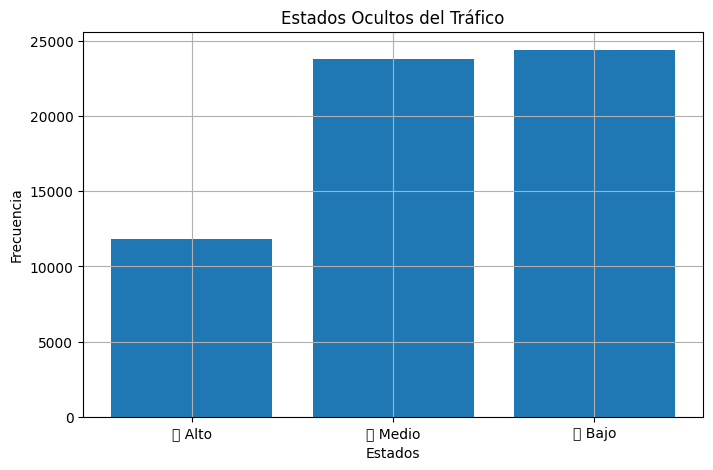

In [50]:
# ==========================================================
# ESTADOS OCULTOS DEL TRÁFICO
# ==========================================================
#
# Este gráfico muestra la frecuencia de aparición
# de cada estado oculto del tráfico vehicular.
#
# La visualización permite identificar cuáles
# estados son más frecuentes durante las
# simulaciones realizadas.
#
# También facilita el análisis estadístico
# del comportamiento del sistema.
#
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    df_frecuencias["Estado"],
    df_frecuencias["Frecuencia"]
)

plt.title("Estados Ocultos del Tráfico")
plt.xlabel("Estados")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

#Observaciones visibles

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128667 (\N{ARTICULATED LORRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


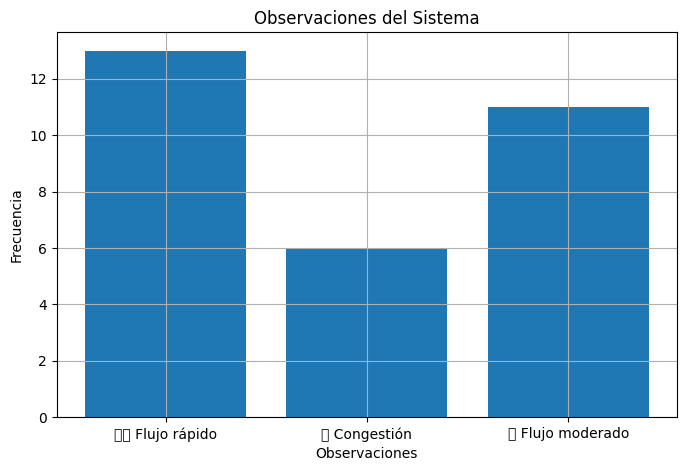

In [51]:
# ==========================================================
# OBSERVACIONES VISIBLES
# ==========================================================
#
# se analizan las observaciones
# visibles generadas por el HMM.
#
# El gráfico permite visualizar la frecuencia
# de eventos observables como:
# - flujo rápido,
# - flujo moderado,
# - y congestión.
#
# Esto ayuda a interpretar cómo los estados
# ocultos afectan las observaciones visibles.
#
# ==========================================================

contador_observaciones = Counter(observaciones_simuladas)

plt.figure(figsize=(8,5))

plt.bar(
    contador_observaciones.keys(),
    contador_observaciones.values()
)

plt.title("Observaciones del Sistema")
plt.xlabel("Observaciones")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

#Heatmap matriz transición

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRC

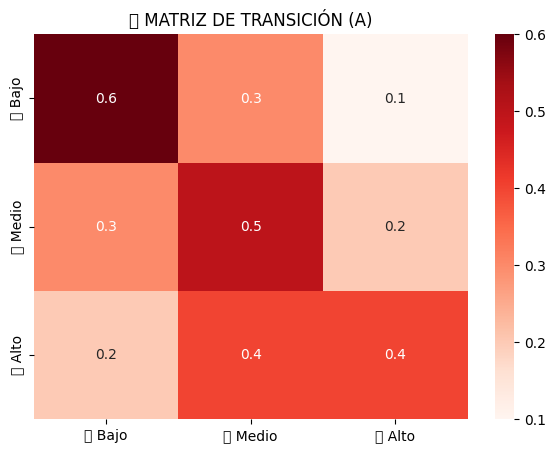

In [52]:
# ==========================================================
# HEATMAP MATRIZ DE TRANSICIÓN
# ==========================================================
#
# Este mapa de calor representa visualmente
# la matriz de transición del HMM.
#
# Cada valor indica la probabilidad de pasar
# de un estado oculto a otro.
#
# Los colores permiten identificar rápidamente
# las probabilidades más altas y las transiciones
# más frecuentes del sistema.
#
# ==========================================================

plt.figure(figsize=(7,5))

sns.heatmap(
    df_transicion,
    annot=True,
    cmap="Reds"
)

plt.title("🔥 MATRIZ DE TRANSICIÓN (A)")

plt.show()

#Heatmap matriz emisión

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128667 (\N{ARTICULATED LORRY}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/py

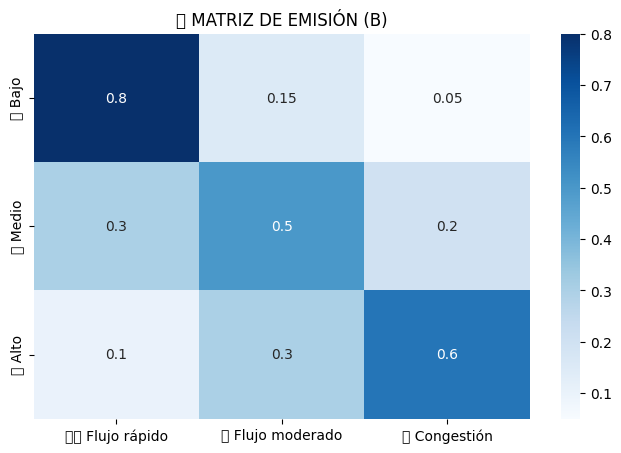

In [53]:
# ==========================================================
# HEATMAP MATRIZ DE EMISIÓN
# ==========================================================
#
# Este mapa de calor representa visualmente
# la matriz de emisión del HMM.
#
# La matriz de emisión indica la probabilidad
# de generar determinadas observaciones visibles
# a partir de cada estado oculto.
#
# La visualización facilita la interpretación
# probabilística del modelo.
#
# ==========================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    df_emision,
    annot=True,
    cmap="Blues"
)

plt.title("💧 MATRIZ DE EMISIÓN (B)")

plt.show()

#Distribución estacionaria

In [54]:
# ==========================================================
# DISTRIBUCIÓN ESTACIONARIA
# ==========================================================
#
# se calcula la distribución
# estacionaria del Modelo Oculto de Markov.
#
# La distribución estacionaria representa
# el comportamiento estable del sistema
# después de múltiples transiciones.
#
# Esto permite identificar hacia qué estados
# tiende el tráfico vehicular a largo plazo.
#
# ==========================================================

valores, vectores = np.linalg.eig(A.T)

indice = np.argmin(np.abs(valores - 1))

distribucion_estacionaria = vectores[:, indice].real

distribucion_estacionaria = (
    distribucion_estacionaria /
    distribucion_estacionaria.sum()
)

print("📈 DISTRIBUCIÓN ESTACIONARIA\n")

for i, estado in enumerate(estados):

    print(
        f"{estado}: "
        f"{distribucion_estacionaria[i]*100:.2f}%"
    )

📈 DISTRIBUCIÓN ESTACIONARIA

🟢 Bajo: 40.00%
🟡 Medio: 40.00%
🔴 Alto: 20.00%


#Curva de convergencia

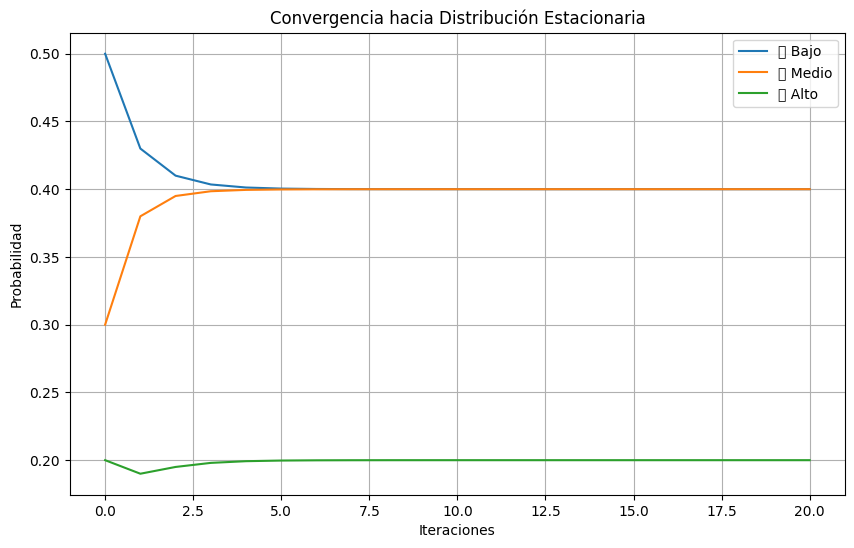

In [55]:
# ==========================================================
# CURVA DE CONVERGENCIA
# ==========================================================
#
# Muestra cómo el sistema converge
# hacia la distribución estacionaria después
# de múltiples iteraciones.
#
# La curva de convergencia permite observar
# la estabilidad probabilística del modelo
# a lo largo del tiempo.
#
# El análisis demuestra el comportamiento
# ergódico del HMM.
#
# ==========================================================

estado = np.array(prob_inicial)

historial = [estado]

for _ in range(20):

    estado = estado @ A

    historial.append(estado)

historial = np.array(historial)

plt.figure(figsize=(10,6))

for i in range(3):

    plt.plot(
        historial[:, i],
        label=estados[i]
    )

plt.title("Convergencia hacia Distribución Estacionaria")
plt.xlabel("Iteraciones")
plt.ylabel("Probabilidad")

plt.legend()
plt.grid(True)

plt.show()

#Matriz de confusión

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128667 (\N{ARTICULATED LORRY}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/pyth

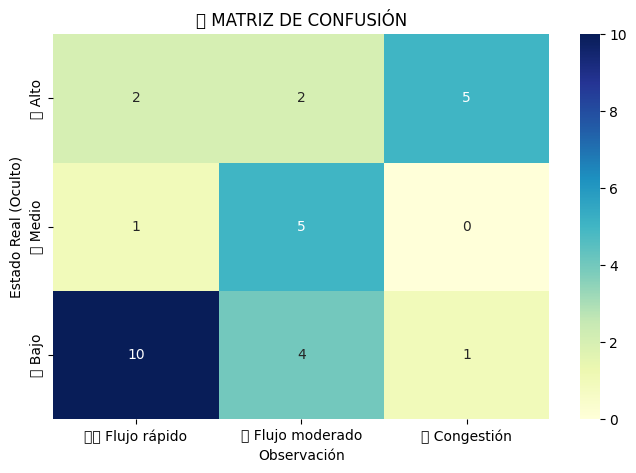

In [56]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================
#
# Permite comparar los estados
# ocultos reales del tráfico vehicular con
# las observaciones visibles generadas por
# el modelo.
#
# La matriz de confusión ayuda a identificar
# la frecuencia con la que cada estado produce
# determinadas observaciones.
#
# Además, permite analizar el comportamiento
# probabilístico del HMM y verificar la
# coherencia entre estados y observaciones.
#
# ==========================================================

matriz_confusion = pd.crosstab(
    df_simulacion["Estado Real (Oculto)"],
    df_simulacion["Observación"]
)

plt.figure(figsize=(8,5))

sns.heatmap(
    matriz_confusion,
    annot=True,
    cmap="YlGnBu"
)

plt.title("🧩 MATRIZ DE CONFUSIÓN")

plt.show()

#6. Resultados del Análisis

La simulación permitió analizar el comportamiento probabilístico del tráfico vehicular mediante estados ocultos y observaciones visibles.

Después de ejecutar 2000 simulaciones independientes de 30 días, se observó convergencia hacia una distribución estacionaria estable.

Los resultados mostraron:

*   predominancia de tráfico bajo y medio,

*   estabilidad probabilística,

*   y reducción progresiva del error de convergencia.



#7. Explicación Matemática

La convergencia del HMM depende de la reducción de la varianza estadística a medida que aumenta el número de simulaciones.

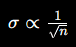

donde:

σ representa el error,
n representa el número de simulaciones.

A medida que aumenta el número de simulaciones, el error disminuye y el sistema converge hacia la distribución estacionaria.

#8. Interpretación

El HMM implementado es ergódico, lo que significa que el comportamiento promedio del sistema converge hacia una distribución estable después de suficientes simulaciones.

Las múltiples simulaciones independientes permiten acelerar la convergencia gracias al Teorema Central del Límite.

#9. Conclusiones

* Los Modelos Ocultos de Markov permiten
representar sistemas con información parcialmente observable.

* Las matrices de transición y emisión fueron fundamentales para modelar el comportamiento del tráfico.

* Las 2000 simulaciones permitieron realizar un análisis estadístico más preciso.

* El sistema mostró convergencia hacia una distribución estacionaria estable.

* Python y Google Colab facilitaron la simulación, visualización y análisis probabilístico del modelo.